In [1]:
import re
import numpy as np
from datetime import datetime

Saving hostel_bois.txt to hostel_bois (2).txt

Messages found: 3174

Participants:
- Aman
- Karan
- Neha
- Priya
- Rahul
- Vikas


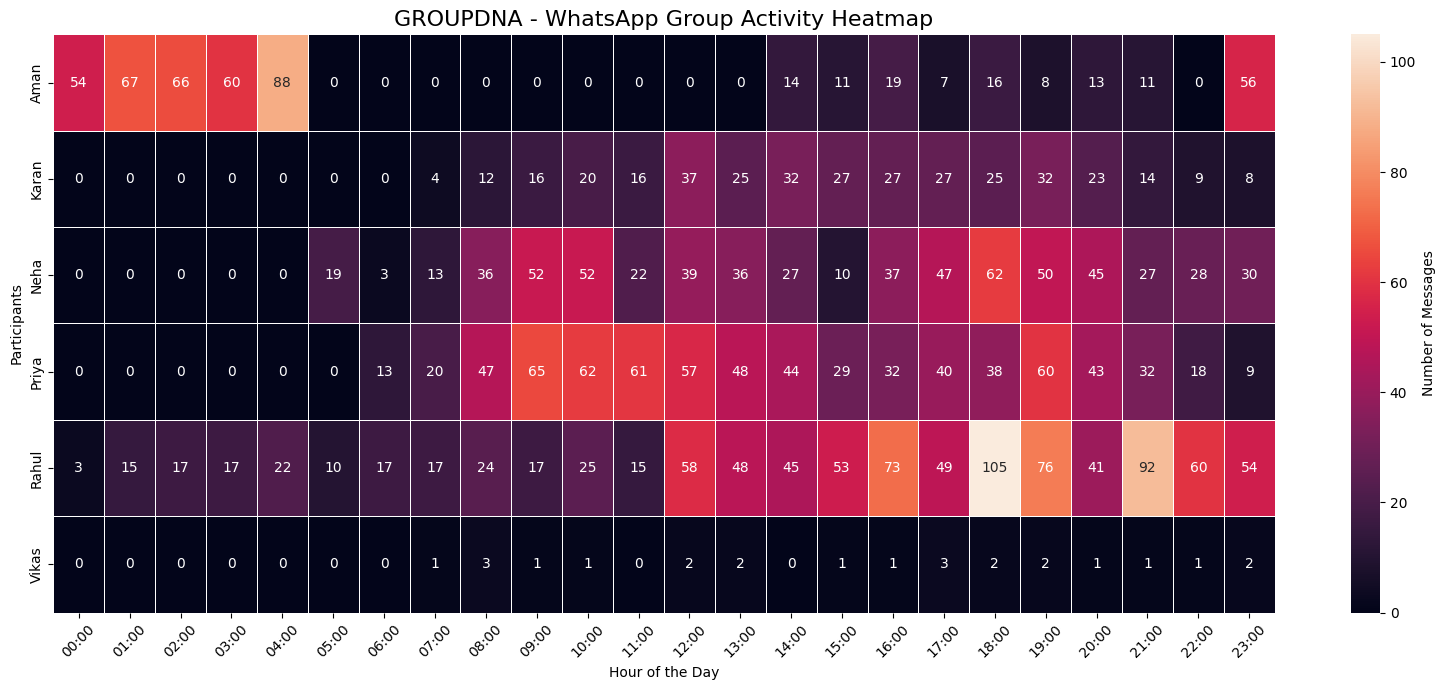



                    GROUPDNA
             WHATSAPP GROUP ANALYZER

GENERAL INFORMATION
------------------------------------------------------------
Total Participants : 6
Total Messages     : 3174

MESSAGE COUNT
------------------------------------------------------------
Aman                      : 490
Karan                     : 354
Neha                      : 635
Priya                     : 718
Rahul                     : 953
Vikas                     : 24

BUSIEST DAY
------------------------------------------------------------
2024-05-04
Messages: 76

BUSIEST HOUR
------------------------------------------------------------
18:00 - 18:59
Messages: 248

TOP 10 WORDS
------------------------------------------------------------
how                  : 321
guys                 : 318
today                : 292
so                   : 292
about                : 274
hai                  : 268
am                   : 260
s                    : 226
my                   : 223
he             

In [4]:
import re
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from collections import Counter
from google.colab import files

uploaded = files.upload()
filename = list(uploaded.keys())[0]

with open(filename, "r", encoding="utf-8") as f:
    lines = f.readlines()

messages = []

for line in lines:
    match = re.match(
        r"(\d{2}/\d{2}/\d{2}, \d{2}:\d{2}) - (.*?): (.*)",
        line.strip()
    )

    if match:
        date, sender, message = match.groups()

        try:
            date = datetime.strptime(date, "%d/%m/%y, %H:%M")

            messages.append({
                "date": date,
                "sender": sender,
                "message": message
            })

        except:
            pass

print("\nMessages found:", len(messages))

people = sorted(set(m["sender"] for m in messages))

print("\nParticipants:")
for person in people:
    print("-", person)

message_count = {}

for person in people:
    count = sum(
        m["sender"] == person
        for m in messages
    )
    message_count[person] = count

days = {}
hours = {}

for m in messages:
    day = m["date"].date()
    hour = m["date"].hour

    days[day] = days.get(day, 0) + 1
    hours[hour] = hours.get(hour, 0) + 1

busiest_day = max(days, key=days.get)
busiest_hour = max(hours, key=hours.get)

heatmap = np.zeros(
    (len(people), 24),
    dtype=int
)

for m in messages:
    person_index = people.index(m["sender"])
    hour = m["date"].hour
    heatmap[person_index][hour] += 1

plt.figure(figsize=(16, 7))

sns.heatmap(
    heatmap,
    annot=True,
    fmt="d",
    xticklabels=[f"{h:02d}:00" for h in range(24)],
    yticklabels=people,
    linewidths=0.5,
    cbar_kws={"label": "Number of Messages"}
)

plt.title(
    "GROUPDNA - WhatsApp Group Activity Heatmap",
    fontsize=16
)

plt.xlabel("Hour of the Day")
plt.ylabel("Participants")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

words = []

for m in messages:
    message_words = re.findall(
        r"\b[a-zA-Z]+\b",
        m["message"].lower()
    )
    words.extend(message_words)

stop_words = {
    "the", "is", "a", "to", "and",
    "of", "in", "for", "on", "it",
    "this", "that", "i", "you",
    "we", "are", "was", "be",
    "have", "has", "with", "at",
    "or", "an", "from", "but"
}

words = [
    word for word in words
    if word not in stop_words
]

top_words = Counter(words).most_common(10)

print("\n")
print("=" * 60)
print("                    GROUPDNA")
print("             WHATSAPP GROUP ANALYZER")
print("=" * 60)

print("\nGENERAL INFORMATION")
print("-" * 60)

print("Total Participants :", len(people))
print("Total Messages     :", len(messages))

print("\nMESSAGE COUNT")
print("-" * 60)

for person, count in message_count.items():
    print(f"{person:<25} : {count}")

print("\nBUSIEST DAY")
print("-" * 60)

print(busiest_day)
print("Messages:", days[busiest_day])

print("\nBUSIEST HOUR")
print("-" * 60)

print(f"{busiest_hour:02d}:00 - {busiest_hour:02d}:59")
print("Messages:", hours[busiest_hour])

print("\nTOP 10 WORDS")
print("-" * 60)

for word, count in top_words:
    print(f"{word:<20} : {count}")

most_active = max(
    message_count,
    key=message_count.get
)

print("\nMOST ACTIVE PARTICIPANT")
print("-" * 60)

print(most_active)
print("Messages:", message_count[most_active])

print("\nPROJECT SUMMARY")
print("-" * 60)

print("GroupDNA analyzed the WhatsApp group chat and identified:")
print("1. Total number of participants")
print("2. Total number of messages")
print("3. Message count of each participant")
print("4. Busiest day")
print("5. Busiest hour")
print("6. Graphical activity heatmap")
print("7. Top 10 frequently used words")
print("8. Most active participant")

print("\n" + "=" * 60)
print("          GROUPDNA ANALYSIS COMPLETED")
print("=" * 60)